# **Análisis y Limpieza de datos - Dataset Spotify 2023**
**Branco Merino Huerta - Ingeniería en Informática - 17 de abril de 2026**


El objetivo de este trabajo es aplicar un pipeline de limpieza y preparación de datos sobre un dataset de canciones de Spotify, con el fin de obtener un conjunto de datos consistente y listo para análisis posteriores.

El dataset a trabajar incluye variables numéricas como popularidad, streams y características musicales (danceability, energy), además de variables categóricas como key y mode.

# 1.0 Cargamos el Dataset de Spotify

In [ ]:
# Importamos la librería pandas, para trabajar con tabulares
import pandas as pd

# Ruta del archivo Excel
# Cambia esta ruta si tu archivo está en otra carpeta
ruta_archivo = "spotify-2023-mod.xlsx"

# Leemos el archivo Excel y lo cargamos en un DataFrame
df = pd.read_excel(ruta_archivo)

# Mostramos las primeras 10 filas del dataset
df.head(10)

,track_name,released_year,released_month,released_day,in_spotify_playlists,streams,key,mode,danceability_%,energy_%
0,Seven (feat. Latto) (Explicit Ver.),2023,7,14,553.0,141381703,B,Major,80.0,83
1,LALA,2023,3,23,1474.0,133716286,C#,Major,71.0,74
2,vampire,2023,6,30,1397.0,140003974,F,Major,51.0,53
3,Cruel Summer,2019,8,23,7858.0,800840817,A,Major,55.0,72
4,WHERE SHE GOES,2023,5,18,3133.0,303236322,A,Minor,65.0,80
5,Sprinter,2023,6,1,2186.0,183706234,C#,Major,92.0,58
6,Ella Baila Sola,2023,3,16,3090.0,725980112,F,Minor,67.0,76
7,Columbia,2023,7,7,714.0,58149378,F,Major,67.0,71
8,fukumean,2023,5,15,NaN,95217315,C#,Minor,85.0,62
9,La Bebe - Remix,2023,3,17,NaN,553634067,D,NaN,NaN,48


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 2.0 Exploración Inicial de los datos

Utilizamos `df.info()` para obtener un resumen rápido de nuestro Dataframe.

Esto nos ayudará a:
- Identificar el número total de filas y columnas.
- Conocer el nombre y el tipo de dato de cada columna.
- Detectar la presencia de valores nulos, lo cual es crucial para la limpieza de datos.


In [ ]:
#Iniciamos el resumen rápido
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 952 entries, 0 to 951
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            952 non-null    object 
 1   released_year         952 non-null    int64  
 2   released_month        952 non-null    int64  
 3   released_day          952 non-null    int64  
 4   in_spotify_playlists  905 non-null    float64
 5   streams               952 non-null    int64  
 6   key                   857 non-null    object 
 7   mode                  905 non-null    object 
 8   danceability_%        905 non-null    float64
 9   energy_%              952 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 74.5+ KB


Posteriormente, utilizaremos `df.describe()` para generar un resumen estadístico de las variables numéricas del dataset. Este resumen incluye medidas de tendencia central, dispersión y posición, lo que nos permite comprender la distribución de los datos y detectar posibles anomalías.

In [ ]:
#Iniciamos el resumen estadístico
df.describe()

,released_year,released_month,released_day,in_spotify_playlists,streams,danceability_%,energy_%
count,952.000000,952.000000,952.000000,905.000000,9.520000e+02,905.000000,952.000000
mean,2018.288866,6.038866,13.944328,5273.350276,5.141374e+08,66.981215,64.274160
std,11.011397,3.564571,9.197223,7991.359501,5.668569e+08,14.700953,16.558517
min,1930.000000,1.000000,1.000000,31.000000,2.762000e+03,23.000000,9.000000
25%,2020.000000,3.000000,6.000000,870.000000,1.416362e+08,57.000000,53.000000
50%,2022.000000,6.000000,13.000000,2224.000000,2.905309e+08,69.000000,66.000000
75%,2022.000000,9.000000,22.000000,5730.000000,6.738690e+08,78.000000,77.000000
max,2023.000000,12.000000,31.000000,52898.000000,3.703895e+09,96.000000,97.000000


## 2.1 Resumen del Diagnóstico de Datos

**Hallazgos Principales:**

*   **Estructura y Calidad:** El dataset cuenta con 952 registros y 10 columnas. Se requiere imputación de datos en variables clave como key, mode y danceability_% debido a valores nulos.

*   **Perfil Temporal:** La mayoría de los lanzamientos son recientes, con una mediana en el año 2022.
*   **Distribución y Sesgos:**

    *   **Alta Volatilidad:** Las variables streams e in_spotify_playlists presentan una alta dispersión, donde el valor máximo es considerablemente superior a la mediana, sugiriendo la presencia de outliers.
    *   **Estabilidad:** Los atributos musicales (danceability_%, energy_%) muestran un comportamiento uniforme.

*   **Acción Inmediata:** Es crítico realizar un tratamiento de valores atípicos en la columna de reproducciones para garantizar la fiabilidad del análisis








# 3.0 Limpieza de datos

Hemos optado por imputar los valores numéricos utilizando la mediana, ya que el dataset presenta valores extremos que pueden distorsionar la media. La mediana, al ser una medida robusta, permite mantener la distribución original sin introducir sesgos.

Para las variables categóricas **(key y mode)**, se utiliza la moda, ya que representa la categoría más frecuente y permite completar los datos de manera coherente.

Este proceso permite obtener un dataset más completo, evitando la pérdida de información que implicaría eliminar filas con valores nulos.

Comenzaremos identificando los valores nulos en el dataset para determinar en que columnas se requiere imputación.

In [ ]:
# Crear tabla resumen
resumen = pd.DataFrame({
    "Tipo de dato": df.dtypes,
    "Valores No Nulos": df.count(),
    "Cantidad nulos": df.isnull().sum(),
    "% nulos": (df.isnull().mean() * 100).round(2).astype(str) + '%',
    "Valores Únicos": df.nunique()
})

# Ordenar por cantidad de nulos para priorizar la limpieza
resumen = resumen.sort_values(by="Cantidad nulos", ascending=False)

# Mostrar tabla
print("Resumen de Calidad de Datos:")
resumen

Resumen de Calidad de Datos:


,Tipo de dato,Valores No Nulos,Cantidad nulos,% nulos,Valores Únicos
key,object,857,95,9.98%,11
in_spotify_playlists,float64,905,47,4.94%,835
mode,object,905,47,4.94%,2
danceability_%,float64,905,47,4.94%,72
released_year,int64,952,0,0.0%,50
track_name,object,952,0,0.0%,942
streams,int64,952,0,0.0%,948
released_day,int64,952,0,0.0%,31
released_month,int64,952,0,0.0%,12
energy_%,int64,952,0,0.0%,80


## 3.1 ¿Qué haremos con los nulos?

Se implementará una función de imputación automatizada que aplica estrategias diferenciadas según la naturaleza de los datos:


*  **Variables Numéricas:** Permite alternar entre media o mediana. El uso de la mediana es clave para mitigar el sesgo provocado por valores extremos (outliers).
*   **Variables Categóricas (object):** Se utiliza la moda, asegurando que los registros faltantes adopten la categoría más representativa sin alterar la coherencia del dataset.

**Valor Agregado:** Esta función estandariza la limpieza de datos, permitiendo una comparación ágil entre distintos métodos de imputación y garantizando la reutilización del código en futuros análisis.

### 3.1.1 Definimos una función bien general

In [ ]:
def imputar_nulos(df, metodo_numerico=1):
    """
    Función para imputar valores nulos en un DataFrame.

    Parámetros:
    - df: DataFrame de pandas
    - metodo_numerico:
        1 -> reemplaza nulos numéricos por la MEDIA
        2 -> reemplaza nulos numéricos por la MEDIANA

    Nota:
    - Las columnas tipo 'object' se imputan siempre con la MODA
    """

    df_imputado = df.copy()

    for col in df_imputado.columns:

        # Si la columna es numérica
        if df_imputado[col].dtype != "object":
            #Imputar por media
            if metodo_numerico == 1:
                valor = df_imputado[col].mean()
                #Imputar por mediana
            elif metodo_numerico == 2:
                valor = df_imputado[col].median()
            else:
                print(f"Método no válido en columna {col}")
                continue

        # Si la columna es categórica, imputado por la moda
        else:
            valor = df_imputado[col].mode()[0]

        # Reemplazo de valores nulos
        df_imputado[col].fillna(valor, inplace=True)

    return df_imputado

### 3.1.2 Ajuste de los Inf

Antes de imputar valores nulos, es necesario verificar y tratar valores infinitos, ya que estos pueden afectar los cálculos estadísticos.

In [ ]:
import numpy as np

# Reemplazar infinitos por NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

## 3.2 Aplicamos la función para imputar los datos

Se seleccionó la imputacion por **mediana** en lugar de la media para las variables numéricas debido a la alta presencia de outliers, principalmente en la variable streams.

Dado que la distribución está significativamente sesgada por éxitos masivos que elevan el promedio, la mediana actúa como una medida más robusta. Su uso permite completar los datos faltantes basándose en el valor central típico, evitando así introducir sesgos que distorsionen el análisis posterior.

In [ ]:
# Usar MEDIA
#df_limpio = imputar_nulos(df, metodo_numerico=1)

# Usar MEDIANA
df_limpio = imputar_nulos(df, metodo_numerico=2)

df_limpio.head()

/tmp/ipykernel_72195/3262325625.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputado[col].fillna(valor, inplace=True)


,track_name,released_year,released_month,released_day,in_spotify_playlists,streams,key,mode,danceability_%,energy_%
0,Seven (feat. Latto) (Explicit Ver.),2023,7,14,553.0,141381703,B,Major,80.0,83
1,LALA,2023,3,23,1474.0,133716286,C#,Major,71.0,74
2,vampire,2023,6,30,1397.0,140003974,F,Major,51.0,53
3,Cruel Summer,2019,8,23,7858.0,800840817,A,Major,55.0,72
4,WHERE SHE GOES,2023,5,18,3133.0,303236322,A,Minor,65.0,80


In [ ]:
#Crear tabla de resumen
resumen = pd.DataFrame({
    "Tipo de dato": df_limpio.dtypes,
    "Valores No Nulos": df_limpio.count(),
    "Cantidad nulos": df_limpio.isnull().sum(),
    "% nulos": (df_limpio.isnull().mean() * 100).round(2)
})
#Mostrar tabla
print("Resumen de Calidad de Datos:")
resumen


Resumen de Calidad de Datos:


,Tipo de dato,Valores No Nulos,Cantidad nulos,% nulos
track_name,object,952,0,0.0
released_year,int64,952,0,0.0
released_month,int64,952,0,0.0
released_day,int64,952,0,0.0
in_spotify_playlists,float64,952,0,0.0
streams,int64,952,0,0.0
key,object,952,0,0.0
mode,object,952,0,0.0
danceability_%,float64,952,0,0.0
energy_%,int64,952,0,0.0


In [ ]:
#Conteo de infinitos(Inf)
print("Infinitos después:", np.isinf(df_limpio.select_dtypes(include=np.number)).sum().sum())

Infinitos después: 0


Después de la imputación, no se observan valores nulos o inf en el dataset, lo que permite continuar con el análisis sin pérdida de información.

# 4.0 Optimización mediante funciones auxiliares

El uso de funciones (def) es una práctica esencial para mejorar la eficiencia y el orden del código. En lugar de duplicar instrucciones, se encapsula la lógica de análisis y visualización para ser reutilizada mediante parámetros.

**Ventajas principales:**

*   **Mantenibilidad:** Reduce errores y facilita actualizaciones al modificar el código en un solo lugar.
*  **Legibilidad:** Permite un flujo de trabajo más limpio y estructurado.
*   **Automatización:** Al invocar una función pasando el DataFrame y la columna, se generan automáticamente cálculos estadísticos (cuartiles, bigotes) y gráficos (boxplots, histogramas) sin intervención manual repetitiva.











## 4.1 FA - Boxplot con estadísticos

In [ ]:
def boxplot_con_estadisticos(df, columna):
    # Importar librerías necesarias para gráficos
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Eliminar valores vacíos (NaN) para evitar errores
    serie = df[columna].dropna()

    # ================================
    # CÁLCULO DE CUARTILES
    # ================================
    # Q1: 25% de los datos están por debajo
    q1 = serie.quantile(0.25)

    # Q2: mediana (valor central)
    q2 = serie.quantile(0.50)

    # Q3: 75% de los datos están por debajo
    q3 = serie.quantile(0.75)

    # ================================
    # CÁLCULO DEL IQR (RANGO INTERCUARTÍLICO)
    # ================================
    # Mide la dispersión de los datos
    iqr = q3 - q1

    # Límites para detectar valores atípicos (outliers)
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    # ================================
    # CÁLCULO DE LOS BIGOTES REALES
    # ================================
    # Valores más extremos dentro del rango permitido
    bigote_inf = serie[serie >= lim_inf].min()
    bigote_sup = serie[serie <= lim_sup].max()

    # ================================
    # CONFIGURACIÓN VISUAL
    # ================================
    sns.set_theme(style="whitegrid", context="talk")

    plt.figure(figsize=(8, 6))

    # Crear el boxplot
    ax = sns.boxplot(
        y=serie,  # datos a graficar
        width=0.25, # Un poco más angosto para dar espacio a etiquetas
        color="#7FB3D5",
        linewidth=2,

        # Estilo de la caja
        boxprops=dict(edgecolor="#1B4F72"),

        # Estilo de líneas (bigotes)
        whiskerprops=dict(color="#1B4F72", linewidth=2),
        capprops=dict(color="#1B4F72", linewidth=2),

        # Estilo de la mediana
        medianprops=dict(color="#C0392B", linewidth=2.5),

        # Estilo de los outliers (puntos)
        flierprops=dict(
            marker='o',
            markerfacecolor='#E74C3C',
            markeredgecolor='#922B21',
            markersize=7,
            linestyle='none',
            alpha=0.8
        )
    )

    # Título y etiquetas
    ax.set_title(f"Boxplot de {columna}", fontsize=16, pad=15)
    ax.set_ylabel(columna, fontsize=13)
    ax.set_xlabel("")

    # ================================
    # AGREGAR TEXTO AL GRÁFICO
    # ================================
    # Formato con separador de miles para legibilidad
    fmt = "{:,.0f}"

    # Bigote inferior (Derecha)
    ax.text(0.22, bigote_inf, f"Mín: {fmt.format(bigote_inf)}",
            va="center", ha="left", fontsize=10, color="#154360", fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9))

    # Q1 (Izquierda)
    ax.text(-0.22, q1, f"Q1: {fmt.format(q1)}",
            va="center", ha="right", fontsize=10, color="#154360", fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9))

    # Mediana (Derecha)
    ax.text(0.22, q2, f"Mediana: {fmt.format(q2)}",
            va="center", ha="left", fontsize=10, color="#7B241C", fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#7B241C", alpha=0.9))

    # Q3 (Izquierda)
    ax.text(-0.22, q3, f"Q3: {fmt.format(q3)}",
            va="center", ha="right", fontsize=10, color="#154360", fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9))

    # Bigote superior (Derecha)
    ax.text(0.22, bigote_sup, f"Máx: {fmt.format(bigote_sup)}",
            va="center", ha="left", fontsize=10, color="#154360", fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9))

    # Ajustar diseño y mostrar gráfico
    plt.tight_layout()
    plt.show()

## 4.2 FA - Boxplot + Histograma

In [ ]:
def boxplot_histograma(df, columna):

    # Importar librerías necesarias
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np

    # Eliminar valores nulos
    serie = df[columna].dropna()

    # Crear intervalos para el histograma
    bins = np.linspace(serie.min(), serie.max(), 40)
    sns.set_theme(style="whitegrid", context="talk")

    # Crear dos gráficos (uno arriba y otro abajo)
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    # Boxplot (arriba)
    sns.boxplot(x=serie, ax=axes[0])
    axes[0].set_title(f"Boxplot de {columna}")

    # Histograma (abajo)
    sns.histplot(serie, bins=bins, kde=True, ax=axes[1])
    axes[1].set_title(f"Histograma de {columna}")

    # Ajustar diseño y mostrar gráfico
    plt.tight_layout()
    plt.show()

## 4.3 FA - Comparar Boxplot

In [ ]:
def comparar_boxplots(df_antes, df_despues, columna):
    import seaborn as sns
    import matplotlib.pyplot as plt

    # ============================================
    # Extraer datos (ANTES y DESPUÉS del tratamiento)
    # ============================================
    # Eliminamos valores nulos para evitar errores en los cálculos
    serie_antes = df_antes[columna].dropna()
    serie_despues = df_despues[columna].dropna()

    # ============================================
    # Función para calcular estadísticos del boxplot
    # ============================================
    def calcular_estadisticos(serie):
        # Cuartiles
        q1 = serie.quantile(0.25)  # 25% de los datos
        q2 = serie.quantile(0.50)  # Mediana
        q3 = serie.quantile(0.75)  # 75% de los datos

        # Rango intercuartílico (IQR)
        iqr = q3 - q1

        # Límites para detectar outliers
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr

        # Bigotes reales (sin considerar outliers)
        bigote_inf = serie[serie >= lim_inf].min()
        bigote_sup = serie[serie <= lim_sup].max()

        return {
            "q1": q1,
            "q2": q2,
            "q3": q3,
            "bigote_inf": bigote_inf,
            "bigote_sup": bigote_sup
        }

    # Calcular estadísticas para ambos casos
    stats_antes = calcular_estadisticos(serie_antes)
    stats_despues = calcular_estadisticos(serie_despues)

    # ============================================
    # Configuración estética del gráfico
    # ============================================
    sns.set_theme(style="whitegrid", context="talk")

    # Crear dos gráficos lado a lado con misma escala
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # ============================================
    # Función para dibujar cada boxplot
    # ============================================
    def dibujar_boxplot(ax, serie, stats, titulo, color_caja):
        sns.boxplot(
            y=serie,
            ax=ax,
            width=0.25, # Reducido un poco para dar aire a las etiquetas
            color=color_caja,
            linewidth=2,
            boxprops=dict(edgecolor="#1B4F72"),
            whiskerprops=dict(color="#1B4F72", linewidth=2),
            capprops=dict(color="#1B4F72", linewidth=2),
            medianprops=dict(color="#C0392B", linewidth=2.5),
            flierprops=dict(
                marker='o',
                markerfacecolor='#E74C3C',
                markeredgecolor='#922B21',
                markersize=6,
                linestyle='none',
                alpha=0.8
            )
        )

        # Títulos y etiquetas
        ax.set_title(titulo, fontsize=15, pad=15)
        ax.set_ylabel(columna, fontsize=12)
        ax.set_xlabel("")

        # Posición de las etiquetas dentro del gráfico
        # Usamos zigzag para evitar solapamiento vertical
        fmt = "{:,.0f}" # Formato con separador de miles

        # Mostrar valores estadísticos directamente en el gráfico
        ax.text(0.22, stats["bigote_sup"], f"Máx: {fmt.format(stats['bigote_sup'])}",
                va="center", ha="left", fontsize=9, color="#154360", fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9))

        ax.text(-0.22, stats["q3"], f"Q3: {fmt.format(stats['q3'])}",
                va="center", ha="right", fontsize=9, color="#154360", fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9))

        ax.text(0.22, stats["q2"], f"Mediana: {fmt.format(stats['q2'])}",
                va="center", ha="left", fontsize=9, color="#7B241C", fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#7B241C", alpha=0.9))

        ax.text(-0.22, stats["q1"], f"Q1: {fmt.format(stats['q1'])}",
                va="center", ha="right", fontsize=9, color="#154360", fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9))

        ax.text(0.22, stats["bigote_inf"], f"Mín: {fmt.format(stats['bigote_inf'])}",
                va="center", ha="left", fontsize=9, color="#154360", fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#154360", alpha=0.9))

    # ============================================
    # Dibujar ambos gráficos
    # ============================================
    dibujar_boxplot(
        axes[0],
        serie_antes,
        stats_antes,
        f"{columna} antes del tratamiento",
        "#F5B7B1"
    )

    dibujar_boxplot(
        axes[1],
        serie_despues,
        stats_despues,
        f"{columna} después del tratamiento",
        "#85C1E9"
    )

    # Título general
    fig.suptitle(f"Comparación de {columna} antes y después del tratamiento de outliers",
                  fontsize=18, y=1.02)

    # Ajuste final
    plt.tight_layout()
    plt.show()

## 4.4 FA - One Hot Encoding

In [ ]:
def aplicar_one_hot(df, columna):
    """
    Aplica One Hot Encoding a una columna categórica.

    Parámetros:
    - df: DataFrame
    - columna: nombre de la columna a transformar

    Retorna:
    - DataFrame con nuevas columnas binarias
    """

    df_out = df.copy()

    # Generar variables dummy
    dummies = pd.get_dummies(df_out[columna], prefix=columna)

    # Eliminar columna original
    df_out = df_out.drop(columns=[columna])

    # Unir nuevas columnas
    df_out = pd.concat([df_out, dummies], axis=1)

    return df_out

## 4.5 FA - Label Encoding

In [ ]:
def aplicar_label_encoding(df, columna, orden=None):
    """
    Aplica Label Encoding a una columna categórica de forma controlada.

    Parámetros:
    - df: DataFrame
    - columna: nombre de la columna a transformar
    - orden: lista opcional con el orden deseado de las categorías

    Retorna:
    - DataFrame con la columna codificada
    - Diccionario de mapeo utilizado
    """

    df_out = df.copy()

    # Definir orden de categorías
    if orden is not None:
        categorias = orden
    else:
        categorias = sorted(df_out[columna].dropna().unique())

    # Crear mapping estable
    mapping = {categoria: i for i, categoria in enumerate(categorias)}

    # Aplicar mapping
    df_out[columna] = df_out[columna].map(mapping)

    return df_out, mapping

# 5.0 Tratamiento de Outliers

Esta etapa se enfoca en mitigar la distorsión causada por valores extremos, especialmente en variables como streams. Debido a su alta dispersión, estos registros pueden sesgar las métricas principales (como la media) y comprometer la fiabilidad del análisis.

Para resolverlo, se aplica un método de identificación y corrección de outliers, logrando así una distribución más robusta y representativa del comportamiento típico de los datos.

In [ ]:
#Mostrar columnas númericas del dataset
cols_num = df_limpio.select_dtypes(include=np.number).columns
cols_num

Index(['released_year', 'released_month', 'released_day',
       'in_spotify_playlists', 'streams', 'danceability_%', 'energy_%'],
      dtype='object')

## 5.1 Visualización de outliers antes del Tratamiento



Comenzaremos con la variable **streams**

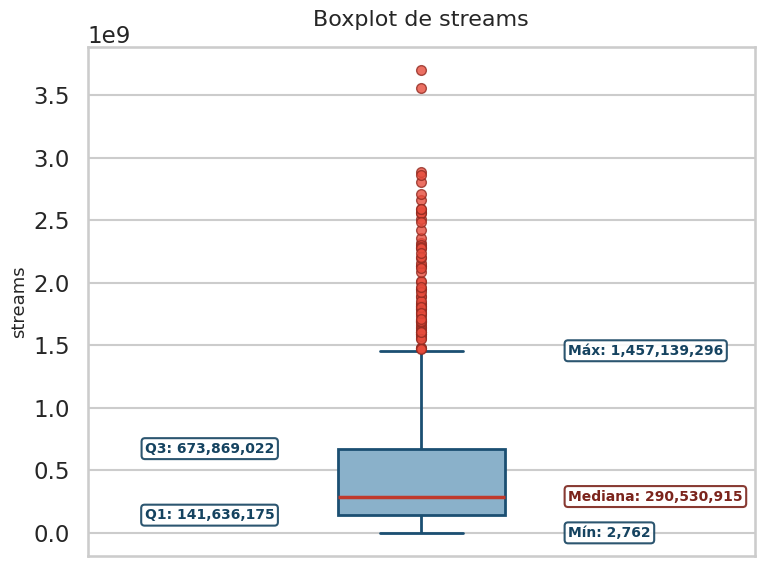

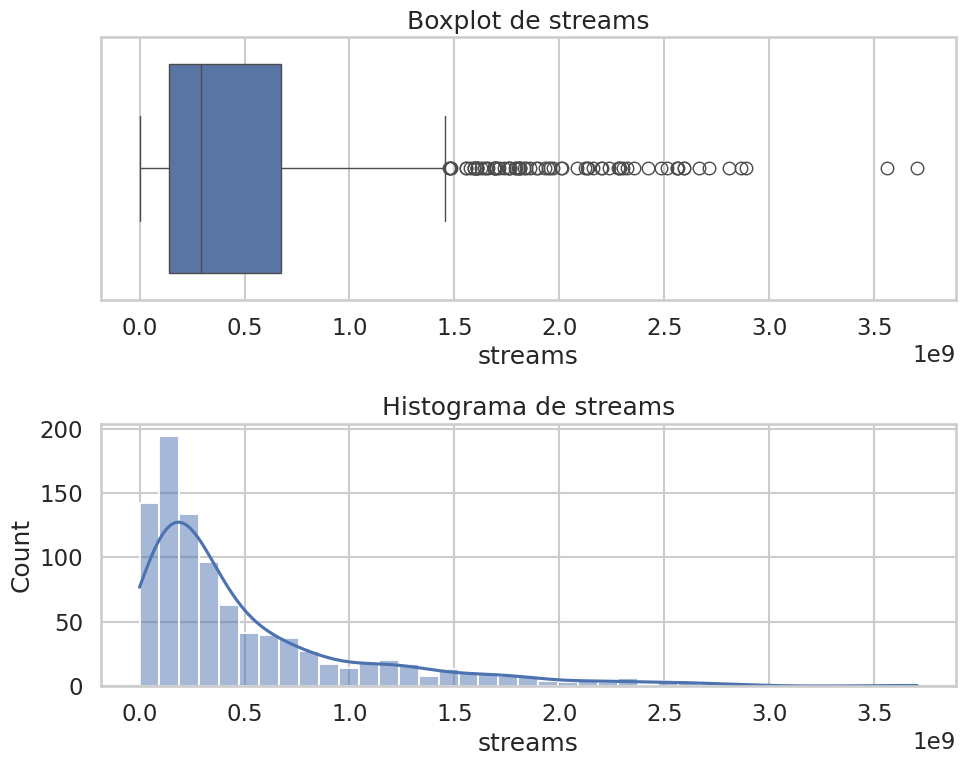

In [ ]:
#Antes: (Base: df_limpio)
#Boxplot detallado
boxplot_con_estadisticos(df_limpio, "streams")
#Boxplot simple + Histograma
boxplot_histograma(df_limpio, "streams")



**NOTA:** Los Valores en estos gráficos (streams) estan en miles de millones,

**Ejemplos:**
*   0.5 → en realidad es 500 millones
*   1.0 → 1.000 millones
*   1.5 → 1.500 millones
*   2.0 → 2.000 millones




Ahora con la variable **in_spotify_playlists"**

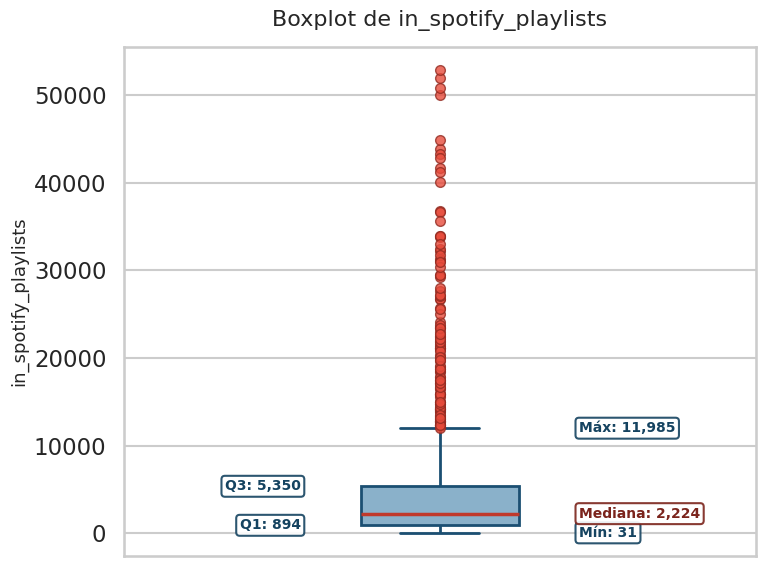

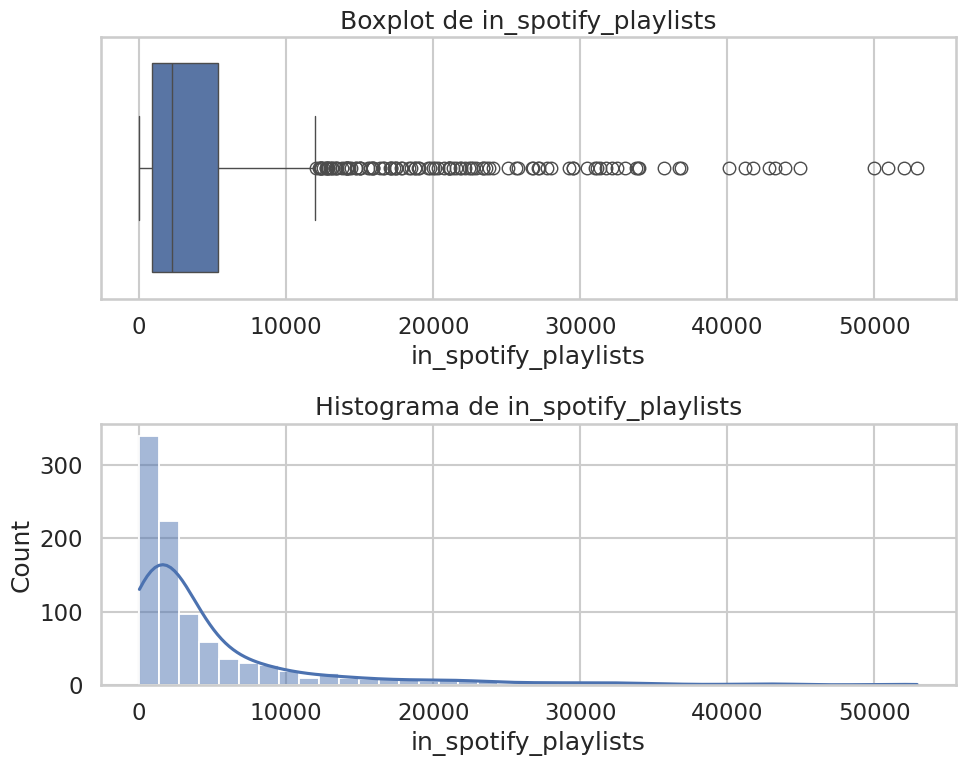

In [ ]:
#Boxplot detallado
boxplot_con_estadisticos(df_limpio, "in_spotify_playlists")
#Boxplot simple + Histograma
boxplot_histograma(df_limpio, "in_spotify_playlists")


Vista rápida de variables **danceability_%** y **energy_%**

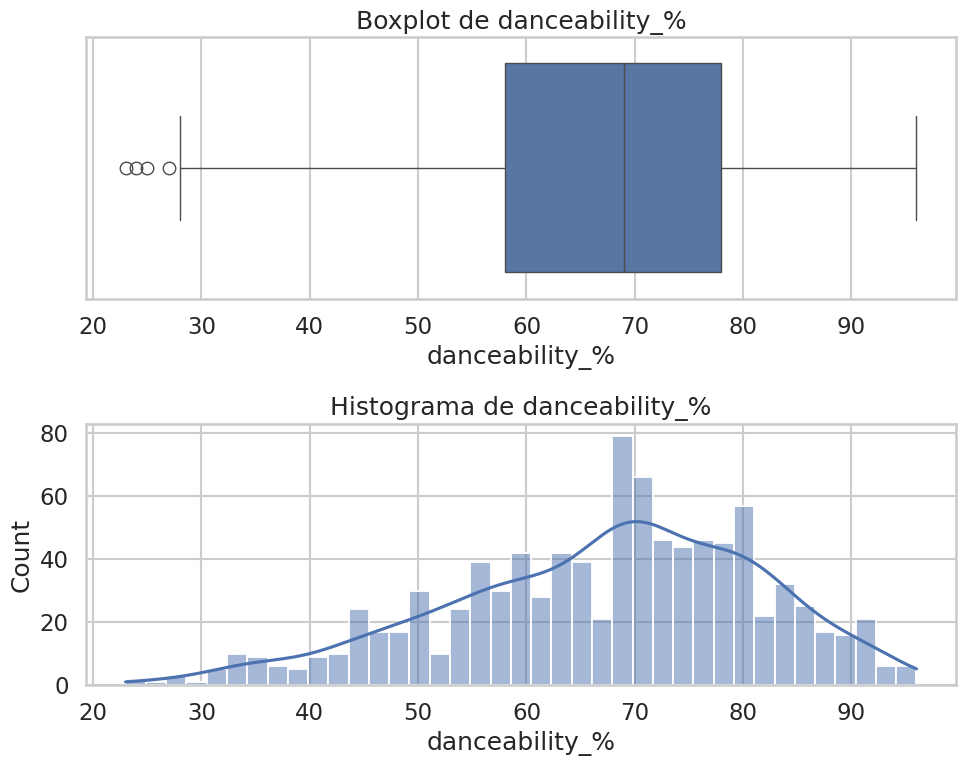

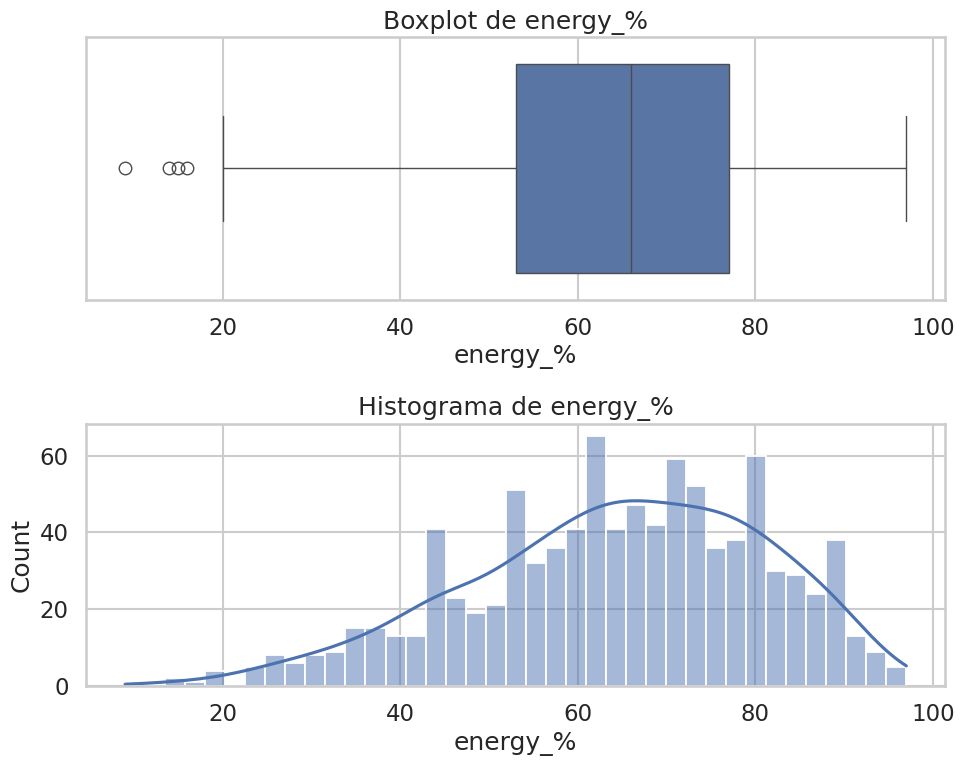

In [ ]:
#Boxplot simple + Histograma
boxplot_histograma(df_limpio, "danceability_%")
#Boxplot simple + Histograma
boxplot_histograma(df_limpio, "energy_%")

### 5.1.1 Interpretación de gráficos

El análisis mediante boxplots revela una distribución fuertemente asimétrica hacia la derecha en las métricas de éxito. Mientras la mayoría de las canciones mantienen niveles moderados de reproducciones (con una mediana cercana a los 290 millones de reproducciones), existe un grupo reducido de "hits" globales que alcanzan cifras extremadamente altas de hasta 3,700 millones.

Estos valores no corresponden a errores, sino a características propias del fenómeno musical, donde pocas canciones concentran gran parte de la popularidad.

## 5.2 Detección de Outliers con IQR



Para detectar valores atípicos en el dataset, se utiliza el método del rango intercuartílico (IQR), el cual permite identificar observaciones que se encuentran fuera de un rango esperado.

Este método se aplica a todas las variables numéricas del dataset, permitiendo detectar outliers de manera sistemática.

Primero se calculan los cuartiles:

* **Q1 (25%): valor bajo el cual se encuentra el 25% de los datos**
* **Q2 (50%): mediana**
* **Q3 (75%): valor bajo el cual se encuentra el 75% de los datos**

Luego se calcula el rango intercuartílico:

* **IQR = Q3 − Q1**

A partir de esto se definen los límites:

* **Límite inferior = Q1 − 1.5 × IQR**
* **Límite superior = Q3 + 1.5 × IQR**

Los valores fuera de este rango se consideran outliers.

### 5.2.1 Funcion tratamiento outliers

In [ ]:
import numpy as np

def tratar_outliers(df, metodo=1):
    """
    Reemplaza outliers en columnas numéricas usando IQR.

    Parámetros:
    - df: DataFrame
    - metodo:
        1 -> reemplaza por MEDIA
        2 -> reemplaza por MEDIANA
    """

    df_out = df.copy()

    for col in df_out.columns:

        # Solo columnas numéricas
        if np.issubdtype(df_out[col].dtype, np.number):

            serie = df_out[col]

            # Calcular IQR
            q1 = serie.quantile(0.25)
            q3 = serie.quantile(0.75)
            iqr = q3 - q1

            lim_inf = q1 - 1.5 * iqr
            lim_sup = q3 + 1.5 * iqr

            # Elegir valor de reemplazo
            if metodo == 1:
                reemplazo = serie.mean()
            elif metodo == 2:
                reemplazo = serie.median()
            else:
                print(f"Método no válido en columna {col}")
                continue
            #Conteo de outlier tratados
            n_out = ((serie < lim_inf) | (serie > lim_sup)).sum()
            print(f"{col}: {n_out} outliers tratados")

            # Reemplazar outliers
            df_out[col] = np.where(
                (serie < lim_inf) | (serie > lim_sup),
                reemplazo,
                serie
            )

    return df_out

## 5.3 Tratamiento final en outliers

Para el tratamiento de los outliers, se decide reemplazarlos en lugar de eliminarlos, con el objetivo de mantener la integridad del dataset.

Se utiliza la mediana como valor de reemplazo, ya que es una medida robusta que no se ve afectada por valores extremos, a diferencia de la media.

Sin embargo, es importante destacar que en el caso de **streams**, los valores extremos corresponden a canciones hits globales, por lo que no representan errores, sino características propias del fenómeno. Por esta razón, su tratamiento se realiza únicamente para estabilizar el análisis estadístico, evitando que estos valores dominen la interpretación general.

In [ ]:
# Reemplazar outliers por media
# df_sin_outliers = tratar_outliers(df_limpio, metodo=1)

# Reemplazar outliers por mediana
df_sin_outliers = tratar_outliers(df_limpio, metodo=2)

df_sin_outliers

released_year: 150 outliers tratados
released_month: 0 outliers tratados
released_day: 0 outliers tratados
in_spotify_playlists: 114 outliers tratados
streams: 74 outliers tratados
danceability_%: 4 outliers tratados
energy_%: 4 outliers tratados


,track_name,released_year,released_month,released_day,in_spotify_playlists,streams,key,mode,danceability_%,energy_%
0,Seven (feat. Latto) (Explicit Ver.),2023.0,7.0,14.0,553.0,141381703.0,B,Major,80.0,83.0
1,LALA,2023.0,3.0,23.0,1474.0,133716286.0,C#,Major,71.0,74.0
2,vampire,2023.0,6.0,30.0,1397.0,140003974.0,F,Major,51.0,53.0
3,Cruel Summer,2019.0,8.0,23.0,7858.0,800840817.0,A,Major,55.0,72.0
4,WHERE SHE GOES,2023.0,5.0,18.0,3133.0,303236322.0,A,Minor,65.0,80.0
...,...,...,...,...,...,...,...,...,...,...
947,My Mind & Me,2022.0,11.0,3.0,953.0,91473363.0,A,Major,60.0,39.0
948,Bigger Than The Whole Sky,2022.0,10.0,21.0,1180.0,121871870.0,F#,Major,42.0,24.0
949,A Veces (feat. Feid),2022.0,11.0,3.0,573.0,73513683.0,C#,Major,80.0,67.0
950,En La De Ella,2022.0,10.0,20.0,1320.0,133895612.0,C#,Major,82.0,77.0


### 5.3.1 Visualización Antes y Después de tratar outliers

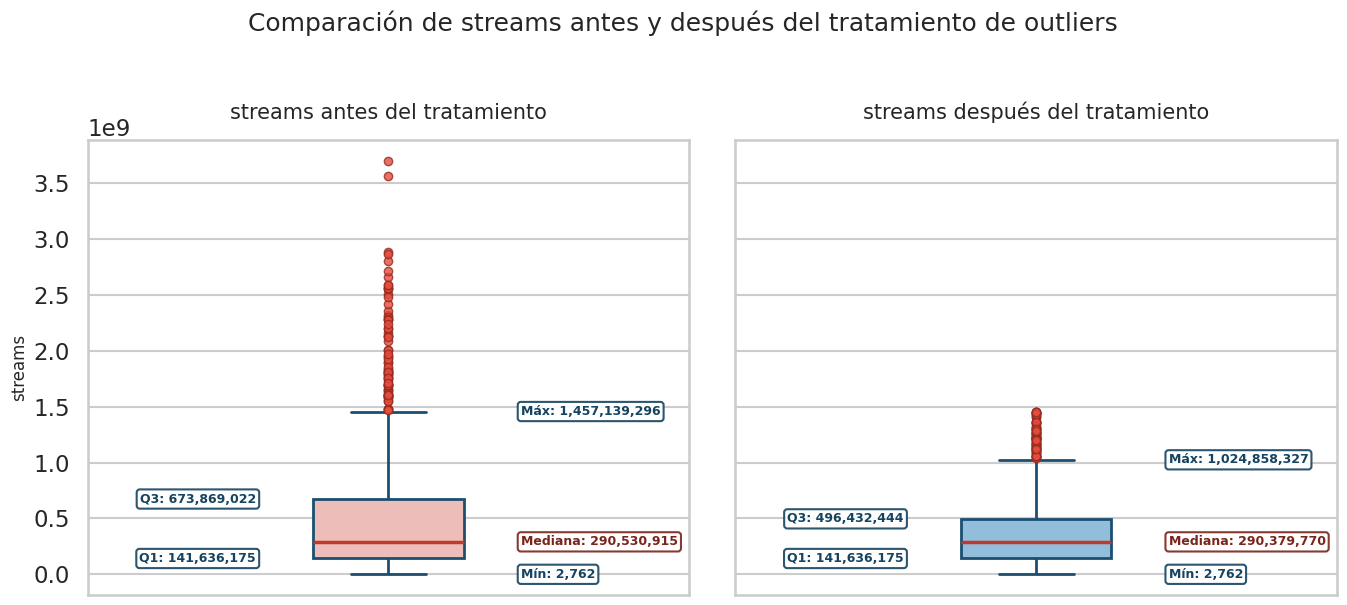

In [ ]:
#Comparación antes y después de variable "streams"
comparar_boxplots(df_limpio, df_sin_outliers, "streams")

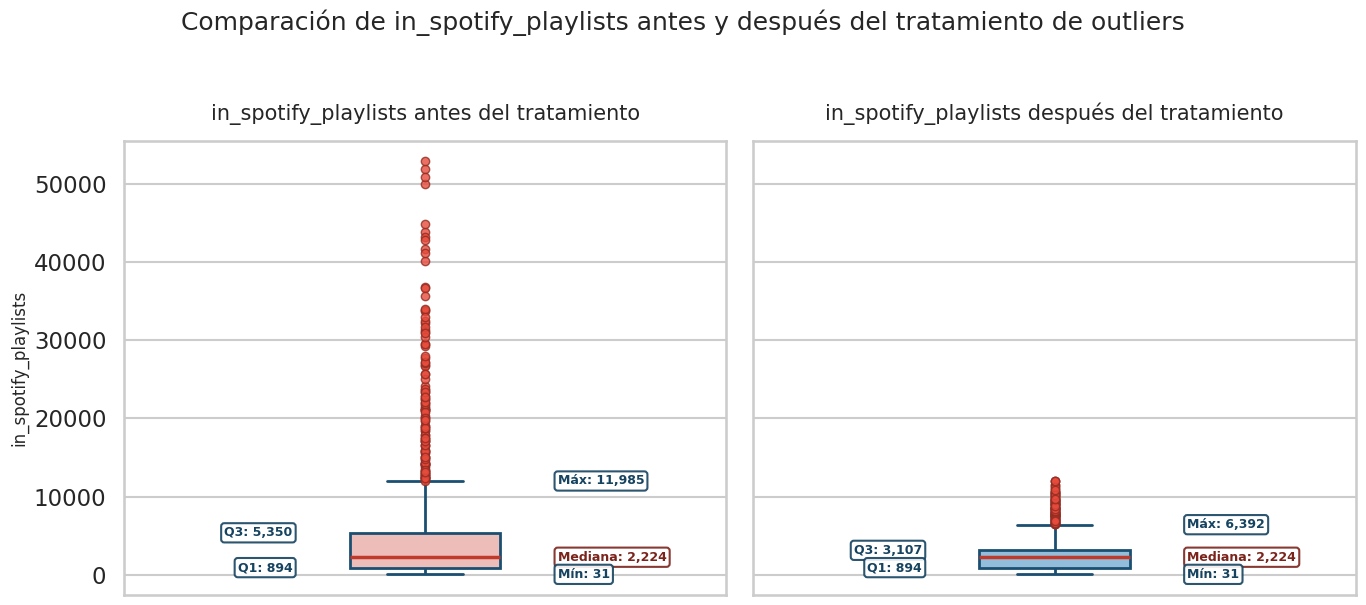

In [ ]:
#Comparación antes y después de variable "in_spotify_playlists"
comparar_boxplots(df_limpio, df_sin_outliers, "in_spotify_playlists")

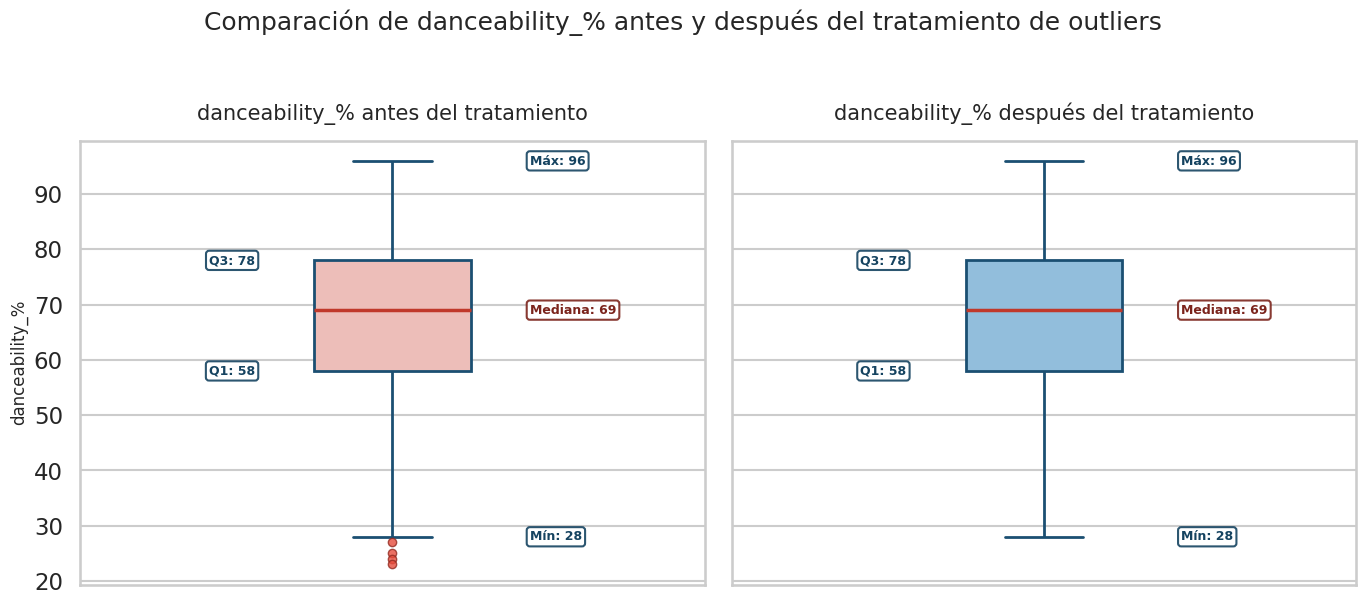

In [ ]:
#Comparación antes y después de variable "danceability_%"
comparar_boxplots(df_limpio, df_sin_outliers, "danceability_%")

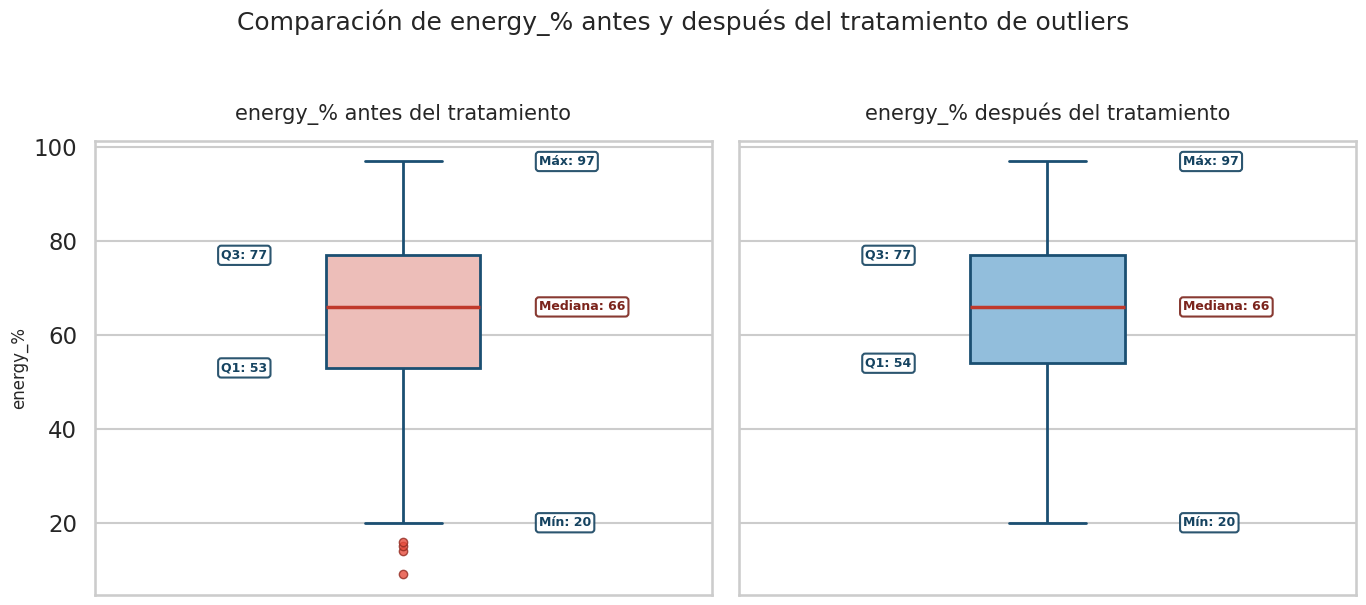

In [ ]:
#Comparación antes y después de variable "energy_%"
comparar_boxplots(df_limpio, df_sin_outliers, "energy_%")

Tras el tratamiento, los valores atípicos dejan de dominar la distribución, permitiendo una representación más equilibrada de los datos. Este ajuste nos ayuda a reducir la influencia de los casos atípicos sin alterar el comportamiento central.

### 5.3.2 Demostración cuantitativa

In [ ]:
# Importamos librerias
import pandas as pd
import numpy as np

# Seleccionar variables numéricas
cols_num = df_limpio.select_dtypes(include=np.number).columns

# Crear comparación
comparacion = pd.DataFrame()

#Iniciamos ciclo para cada columna
for col in cols_num:
    # Definimos antes y el después
    antes = df_limpio[col]
    despues = df_sin_outliers[col]

    # Calcular métricas
    comparacion.loc[col, "Media antes"] = antes.mean()
    comparacion.loc[col, "Media después"] = despues.mean()
    comparacion.loc[col, "Mediana antes"] = antes.median()
    comparacion.loc[col, "Mediana después"] = despues.median()
    comparacion.loc[col, "Max antes"] = antes.max()
    comparacion.loc[col, "Max después"] = despues.max()
    comparacion.loc[col, "Desviación estándar antes"] = antes.std()
    comparacion.loc[col, "Desviación estándar después"] = despues.std()

# Redondear para mejor lectura
comparacion = comparacion.round(0)

comparacion

,Media antes,Media después,Mediana antes,Mediana después,Max antes,Max después,Desviación estándar antes,Desviación estándar después
released_year,2018.0,2022.0,2022.0,2022.0,2.023000e+03,2.023000e+03,11.0,1.0
released_month,6.0,6.0,6.0,6.0,1.200000e+01,1.200000e+01,4.0,4.0
released_day,14.0,14.0,13.0,13.0,3.100000e+01,3.100000e+01,9.0,9.0
in_spotify_playlists,5123.0,2641.0,2224.0,2224.0,5.289800e+04,1.198500e+04,7819.0,2435.0
streams,514137425.0,379028487.0,290530915.0,290379770.0,3.703895e+09,1.457139e+09,566856949.0,334168551.0
danceability_%,67.0,67.0,69.0,69.0,9.600000e+01,9.600000e+01,14.0,14.0
energy_%,64.0,64.0,66.0,66.0,9.700000e+01,9.700000e+01,17.0,16.0


**Explicación del Cambio**

La reducción en la desviación estándar y en los valores máximos confirma que los datos extremos han sido controlados.
Podemos observar que la variable **"streams"** presenta el mayor cambio, lo que indica que era la mayormente afectada por valores atípicos.
En contraste, otras variables muestran variaciones menores, evidenciando una menor influencia de outliers.

# 6.0 Codificación de Variables Categóricas

En esta sección se transforman las variables categóricas a formato numérico, ya que la mayoría de los algoritmos de análisis y modelos requieren datos numéricos para su funcionamiento.

**Comenzamos identificando las variables categóricas**

In [ ]:
df_sin_outliers.select_dtypes(include="object").columns

Index(['track_name', 'key', 'mode'], dtype='object')

Se identifican las variables categóricas del dataset, en este caso **key y mode**, que representan información musical (tonalidad y modo).

## 6.1 Elección del método de Codificación

Para la codificación de las variables categóricas **"key" y "mode"**, se evalúan dos métodos comunes: **Label Encoding** y **One Hot Encoding.**

El **Label Encoding** consiste en asignar un número entero a cada categoría (por ejemplo: C=0, D=1, E=2).

Por otro lado, el **One Hot Encoding** crea una nueva columna binaria (0 o 1) para cada categoría, indicando su presencia o ausencia.

En nuestro caso, la variable **key** representa la tonalidad musical de la canción y contiene múltiples categorías sin un orden jerárquico, por lo que se utiliza **One Hot Encoding** para evitar introducir relaciones artificiales entre ellas. En cambio, la variable **mode** indica si la tonalidad es mayor o menor, por lo que al ser binaria se codifica mediante **Label Encoding**, ya que permite una representación más simple y eficiente sin aumentar la dimensionalidad del dataset.
Cabe destacar que el **One Hot Encoding** tiene como desventaja el incremento en la cantidad de columnas, lo que puede afectar el rendimiento en modelos más complejos; sin embargo, en este caso es necesario para representar correctamente la variable **key**.

## 6.2 One Hot Encoding y Label Encoding

In [ ]:
# Aplicar One Hot Encoding a 'key'
df_codificado = aplicar_one_hot(df_sin_outliers, "key")

# Aplicar Label Encoding a 'mode'
df_codificado, mapping_mode = aplicar_label_encoding(
    df_codificado,
    "mode",
    orden=["Minor", "Major"]
)

#Ver Resultado
df_codificado

,track_name,released_year,released_month,released_day,in_spotify_playlists,streams,mode,danceability_%,energy_%,key_A,key_A#,key_B,key_C#,key_D,key_D#,key_E,key_F,key_F#,key_G,key_G#
0,Seven (feat. Latto) (Explicit Ver.),2023.0,7.0,14.0,553.0,141381703.0,1,80.0,83.0,False,False,True,False,False,False,False,False,False,False,False
1,LALA,2023.0,3.0,23.0,1474.0,133716286.0,1,71.0,74.0,False,False,False,True,False,False,False,False,False,False,False
2,vampire,2023.0,6.0,30.0,1397.0,140003974.0,1,51.0,53.0,False,False,False,False,False,False,False,True,False,False,False
3,Cruel Summer,2019.0,8.0,23.0,7858.0,800840817.0,1,55.0,72.0,True,False,False,False,False,False,False,False,False,False,False
4,WHERE SHE GOES,2023.0,5.0,18.0,3133.0,303236322.0,0,65.0,80.0,True,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947,My Mind & Me,2022.0,11.0,3.0,953.0,91473363.0,1,60.0,39.0,True,False,False,False,False,False,False,False,False,False,False
948,Bigger Than The Whole Sky,2022.0,10.0,21.0,1180.0,121871870.0,1,42.0,24.0,False,False,False,False,False,False,False,False,True,False,False
949,A Veces (feat. Feid),2022.0,11.0,3.0,573.0,73513683.0,1,80.0,67.0,False,False,False,True,False,False,False,False,False,False,False
950,En La De Ella,2022.0,10.0,20.0,1320.0,133895612.0,1,82.0,77.0,False,False,False,True,False,False,False,False,False,False,False


Verificación final

Verificamos que las columnas originales en key han sido eliminadas y reemplazadas por variables binarias, confirmando que el proceso se realizó correctamente.

In [ ]:
#Ver nueva codificación
df_codificado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 952 entries, 0 to 951
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            952 non-null    object 
 1   released_year         952 non-null    float64
 2   released_month        952 non-null    float64
 3   released_day          952 non-null    float64
 4   in_spotify_playlists  952 non-null    float64
 5   streams               952 non-null    float64
 6   mode                  952 non-null    int64  
 7   danceability_%        952 non-null    float64
 8   energy_%              952 non-null    float64
 9   key_A                 952 non-null    bool   
 10  key_A#                952 non-null    bool   
 11  key_B                 952 non-null    bool   
 12  key_C#                952 non-null    bool   
 13  key_D                 952 non-null    bool   
 14  key_D#                952 non-null    bool   
 15  key_E                 9

Tras la codificación, todas las variables relevantes para el análisis se encuentran en formato numérico.La variable **"track_name"** se mantiene sin cambios, ya que corresponde a un identificador textual de las canciones y no aporta valor en cálculos numéricos.

# 7.0 Exportación del Dataset

El dataset final se exporta en formato CSV y Excel bajo el nombre `spotify_limpio`. Al utilizar el párametro `index=False`, nos aseguramos de no incluir la columna de índices de pandas, de modo que el archivo contenga únicamente las variables del dataset.

El conjunto de datos resultante se encuentra limpio, sin valores nulos, con outliers tratados y variables categóricas codificadas, lo que lo hace apto para análisis estadísticos y modelos predictivos.

In [ ]:
#Exportación a csv
df_codificado.to_csv("spotify_limpio.csv", index=False)

In [ ]:
#Exportación a excel
df_codificado.to_excel("spotify_limpio.xlsx", index=False)

En este proceso se aplicó un flujo completo de limpieza y transformación de datos, incluyendo imputación de valores nulos, tratamiento de outliers y codificación de variables categóricas.

Finalmente, este proceso demuestra cómo la correcta limpieza y transformación de datos impacta directamente en la calidad y confiabilidad de los análisis posteriores.

Esto evidencia que la calidad del análisis depende directamente de las decisiones tomadas en la etapa de preparación de datos.
